In [8]:
import pandas as pd
import numpy as np
import os

path_prefix = "marketingprojectdata/"

print("Checking directory contents for verification...")
files_present = os.listdir(path_prefix) if path_prefix else os.listdir('.')
print(f"Found {len(files_present)} files/folders in the target directory.")

Checking directory contents for verification...
Found 9 files/folders in the target directory.


In [9]:
print("Loading core datasets...")

customers = pd.read_csv(f'{path_prefix}olist_customers_dataset.csv')
orders = pd.read_csv(f'{path_prefix}olist_orders_dataset.csv')
order_items = pd.read_csv(f'{path_prefix}olist_order_items_dataset.csv')
payments = pd.read_csv(f'{path_prefix}olist_order_payments_dataset.csv')
reviews = pd.read_csv(f'{path_prefix}olist_order_reviews_dataset.csv')

# --- DEBUG CHECKS ---
print("\n--- DEBUG: Row Counts Loaded ---")
print(f"Customers rows: {customers.shape[0]:,}")
print(f"Orders rows:    {orders.shape[0]:,}")
print(f"Items rows:     {order_items.shape[0]:,}")
print(f"Payments rows:  {payments.shape[0]:,}")
print(f"Reviews rows:   {reviews.shape[0]:,}")

Loading core datasets...

--- DEBUG: Row Counts Loaded ---
Customers rows: 99,441
Orders rows:    99,441
Items rows:     112,650
Payments rows:  103,886
Reviews rows:   99,224


In [10]:
print("Aggregating transactional files to the unique Order level...")

# 1. Sum up payments per order
order_payments_agg = payments.groupby('order_id')['payment_value'].sum().reset_index()

# 2. Total items and total revenue per order
order_items_agg = order_items.groupby('order_id').agg(
    items_count=('product_id', 'count'),
    items_total_price=('price', 'sum')
).reset_index()

# 3. Average review score per order
order_reviews_agg = reviews.groupby('order_id')['review_score'].mean().reset_index()

# --- DEBUG CHECKS ---
print("\n--- DEBUG: Aggregated Shapes (Should match or be less than original) ---")
print(f"Aggregated Payments unique orders: {order_payments_agg.shape[0]:,}")
print(f"Aggregated Items unique orders:    {order_items_agg.shape[0]:,}")
print(f"Aggregated Reviews unique orders:  {order_reviews_agg.shape[0]:,}")

Aggregating transactional files to the unique Order level...

--- DEBUG: Aggregated Shapes (Should match or be less than original) ---
Aggregated Payments unique orders: 99,440
Aggregated Items unique orders:    98,666
Aggregated Reviews unique orders:  98,673


In [11]:
print("Building Order Master Dataframe...")

# Format timestamps
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Filter for completed/delivered orders to keep data clean
completed_orders = orders[orders['order_status'] == 'delivered'].copy()
print(f"Filtered for 'delivered' status: {completed_orders.shape[0]:,} orders remaining.")

# Master merge at the order level
order_master = completed_orders[['order_id', 'customer_id', 'order_purchase_timestamp']].copy()
order_master = order_master.merge(order_payments_agg, on='order_id', how='left')
order_master = order_master.merge(order_items_agg, on='order_id', how='left')
order_master = order_master.merge(order_reviews_agg, on='order_id', how='left')

# Link order to the TRUE customer ID (customer_unique_id)
order_customer_master = order_master.merge(
    customers[['customer_id', 'customer_unique_id', 'customer_state']], 
    on='customer_id', 
    how='inner'
)

# --- DEBUG CHECKS ---
print(f"Final Order Master dataset size: {order_customer_master.shape[0]:,} rows.")
order_customer_master.head(3)

Building Order Master Dataframe...
Filtered for 'delivered' status: 96,478 orders remaining.
Final Order Master dataset size: 96,478 rows.


,order_id,customer_id,order_purchase_timestamp,payment_value,items_count,items_total_price,review_score,customer_unique_id,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,38.71,1,29.99,4.0,7c396fd4830fd04220f754e42b4e5bff,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,141.46,1,118.70,4.0,af07308b275d755c9edb36a90c618231,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,179.12,1,159.90,5.0,3a653a41f6f9fc3d2a113cf8398680e8,GO


In [12]:
print("Rolling up to ultimate Master Customer Profiles...")

# Establish the timeline anchor (the most recent date in the entire dataset)
max_date = order_customer_master['order_purchase_timestamp'].max()
print(f"Dataset baseline date ('Today'): {max_date}")

# Final aggregation by unique human being
customer_profiles = order_customer_master.groupby('customer_unique_id').agg(
    total_spend=('payment_value', 'sum'),
    total_orders=('order_id', 'nunique'),
    total_items_bought=('items_count', 'sum'),
    avg_review_score=('review_score', 'mean'),
    last_purchase_date=('order_purchase_timestamp', 'max'),
    customer_state=('customer_state', 'first')
).reset_index()

# Calculate Recency: how many days ago was their last order?
customer_profiles['recency_days'] = (max_date - customer_profiles['last_purchase_date']).dt.days
customer_profiles = customer_profiles.drop(columns=['last_purchase_date'])

# Handle missing values cleanly
customer_profiles['avg_review_score'] = customer_profiles['avg_review_score'].fillna(4.0)
customer_profiles = customer_profiles.fillna(0)

# --- FINAL DEBUG CHECK ---
print(f"\n Successful. Generated profiles for {customer_profiles.shape[0]:,} unique customers.")
customer_profiles.head()

Rolling up to ultimate Master Customer Profiles...
Dataset baseline date ('Today'): 2018-08-29 15:00:37

 Successful. Generated profiles for 93,358 unique customers.


,customer_unique_id,total_spend,total_orders,total_items_bought,avg_review_score,customer_state,recency_days
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,1,5.0,SP,111
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,1,4.0,SP,114
2,0000f46a3911fa3c0805444483337064,86.22,1,1,3.0,SC,536
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,1,1,4.0,PA,320
4,0004aac84e0df4da2b147fca70cf8255,196.89,1,1,5.0,SP,287


In [13]:
print("Step 1/3: Assigning randomized Treatment/Control groups...")

# Set a random seed so your results are perfectly reproducible
np.random.seed(42)

# Generate a binary flag (0 or 1) with a 50/50 chance for every row
customer_profiles['treatment'] = np.random.binomial(1, 0.5, size=len(customer_profiles))

# Verify the split is roughly 50/50
treatment_counts = customer_profiles['treatment'].value_counts()
print(f"Control group (No Coupon): {treatment_counts[0]:,}")
print(f"Treatment group (Coupon):  {treatment_counts[1]:,}")

Step 1/3: Assigning randomized Treatment/Control groups...
Control group (No Coupon): 46,568
Treatment group (Coupon):  46,790


In [15]:
print("Step 2/3: Calculating baseline probabilities and applying causal uplift...")

# 1. Initialize baseline conversion probability (everyone has a small background chance to buy again)
# Active buyers who left good reviews have a much higher baseline chance.
base_prob = 0.05 + (0.20 * (customer_profiles['recency_days'] < 60)) + (0.05 * (customer_profiles['avg_review_score'] >= 4))

# 2. Initialize the hidden uplift effect (tau) as 0 for everyone
uplift_effect = np.zeros(len(customer_profiles))

# Define Segment Rules:
# Rule A: The Persuadables (Moderate recency, decent past spend -> Coupon works beautifully)
persuadable_mask = (customer_profiles['recency_days'].between(60, 200)) & (customer_profiles['total_spend'] > 50)
uplift_effect[persuadable_mask] = 0.25 # Coupon increases conversion chance by 25%!

# Rule B: The Sleeping Dogs (Angry customers -> Coupon triggers a negative reaction)
sleeping_dog_mask = (customer_profiles['avg_review_score'] <= 2.0)
uplift_effect[sleeping_dog_mask] = -0.15 # Coupon REDUCES conversion chance by 15%!

# Rule C: The Sure Things (Super active -> Coupon has no incremental value, they buy anyway)
sure_thing_mask = (customer_profiles['recency_days'] < 30) & (customer_profiles['avg_review_score'] >= 4)
uplift_effect[sure_thing_mask] = 0.02 # Minimal change because baseline is already near max

# 3. Calculate Final Probability based on whether they actually received the treatment
final_prob = base_prob + (customer_profiles['treatment'] * uplift_effect)

# Clip probabilities between 0 and 1 so the math stays valid
final_prob = np.clip(final_prob, 0.0, 1.0)

# 4. Simulate the final target outcome (1 = Converted/Purchased, 0 = Did not purchase)
customer_profiles['converted'] = np.random.binomial(1, final_prob)

print("Simulation processing complete!")

Step 2/3: Calculating baseline probabilities and applying causal uplift...
Simulation processing complete!


In [17]:
print("Step 3/3: Validating our simulated universe...\n")

# Let's label our hidden segments in a temporary dataframe to look at the numbers
temp_df = customer_profiles.copy()
temp_df['segment'] = 'Lost Causes / Others'
temp_df.loc[(temp_df['recency_days'].between(60, 200)) & (temp_df['total_spend'] > 50), 'segment'] = 'Persuadables'
temp_df.loc[temp_df['avg_review_score'] <= 2.0, 'segment'] = 'Sleeping Dogs'
temp_df.loc[(temp_df['recency_days'] < 30) & (temp_df['avg_review_score'] >= 4), 'segment'] = 'Sure Things'

# Calculate actual conversion rates per segment and treatment status
validation = temp_df.groupby(['segment', 'treatment'])['converted'].mean().unstack()
validation['actual_uplift'] = validation[1] - validation[0]

print("--- CONVERSION RATES BY SEGMENT ---")
print("Treatment 0 = No Coupon | Treatment 1 = Got Coupon\n")
print(validation)

Step 3/3: Validating our simulated universe...

--- CONVERSION RATES BY SEGMENT ---
Treatment 0 = No Coupon | Treatment 1 = Got Coupon

treatment                    0         1  actual_uplift
segment                                                
Lost Causes / Others  0.117951  0.116170      -0.001781
Persuadables          0.093398  0.342899       0.249501
Sleeping Dogs         0.069123  0.011451      -0.057672
Sure Things           0.315113  0.318262       0.003150


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt
import seaborn as sns

print("Step 1/3: Preparing data and splitting into Train/Test sets...")

# Define our feature columns (The only things the AI is allowed to see)
features = ['total_spend', 'total_orders', 'total_items_bought', 'avg_review_score', 'recency_days']

X = customer_profiles[features]
y = customer_profiles['converted']
treat = customer_profiles['treatment']

# Split into 70% Training and 30% Testing
X_train, X_test, y_train, y_test, treat_train, treat_test = train_test_split(
    X, y, treat, test_size=0.3, random_state=42
)

# Isolate Treatment and Control groups WITHIN the training set
X_train_ctrl = X_train[treat_train == 0]
y_train_ctrl = y_train[treat_train == 0]

X_train_trtm = X_train[treat_train == 1]
y_train_trtm = y_train[treat_train == 1]

print(f"Training set size: {X_train.shape[0]:,}")
print(f"  └─ Control rows:  {X_train_ctrl.shape[0]:,}")
print(f"  └─ Treatment rows:{X_train_trtm.shape[0]:,}")
print(f"Testing set size:  {X_test.shape[0]:,}")

Step 1/3: Preparing data and splitting into Train/Test sets...
Training set size: 65,350
  └─ Control rows:  32,633
  └─ Treatment rows:32,717
Testing set size:  28,008


In [19]:
print("Step 2/3: Training the T-Learner Models (This might take 10-15 seconds)...")

# Brain 0: What happens naturally without a coupon?
print("Training Model 0 (Control Specialist)...")
model_ctrl = GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=4)
model_ctrl.fit(X_train_ctrl, y_train_ctrl)

# Brain 1: What happens when we intervene with a coupon?
print("Training Model 1 (Treatment Specialist)...")
model_trtm = GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=4)
model_trtm.fit(X_train_trtm, y_train_trtm)

print(" Both models successfully trained!")

Step 2/3: Training the T-Learner Models (This might take 10-15 seconds)...
Training Model 0 (Control Specialist)...
Training Model 1 (Treatment Specialist)...
 Both models successfully trained!


Step 3/3: Scoring the Test Set and calculating Uplift Scores...

--- Summary of Predicted Uplift Scores ---
count    28008.000000
mean         0.049394
std          0.113205
min         -0.568826
25%         -0.009148
50%          0.005729
75%          0.072836
max          0.789402
Name: uplift_score, dtype: float64


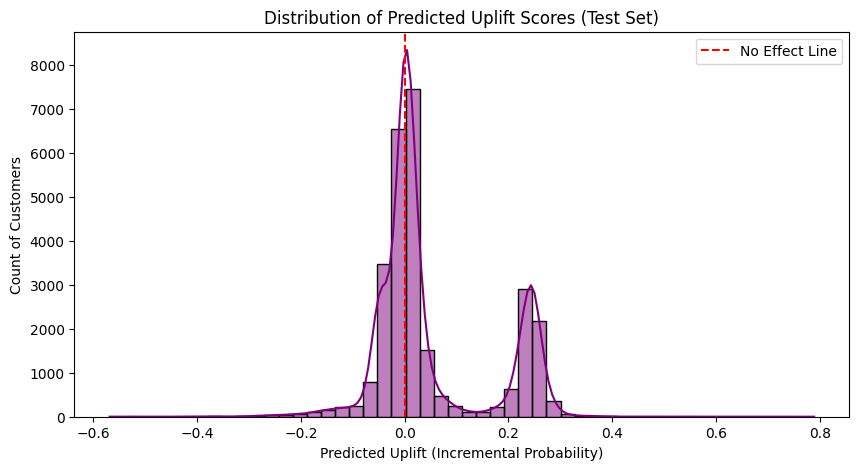

In [21]:
print("Step 3/3: Scoring the Test Set and calculating Uplift Scores...")

# Get probability of purchase (class 1) from both models for the test set
prob_ctrl = model_ctrl.predict_proba(X_test)[:, 1]
prob_trtm = model_trtm.predict_proba(X_test)[:, 1]

# Calculate the individual Uplift Score!
uplift_scores = prob_trtm - prob_ctrl

# Attach the scores to a clean test results summary dataframe
test_results = X_test.copy()
test_results['treatment'] = treat_test
test_results['converted'] = y_test
test_results['uplift_score'] = uplift_scores

print("\n--- Summary of Predicted Uplift Scores ---")
print(test_results['uplift_score'].describe())

# Plot the distribution of the uplift scores
plt.figure(figsize=(10, 5))
sns.histplot(test_results['uplift_score'], bins=50, kde=True, color='purple')
plt.title('Distribution of Predicted Uplift Scores (Test Set)')
plt.xlabel('Predicted Uplift (Incremental Probability)')
plt.ylabel('Count of Customers')
plt.axvline(x=0, color='red', linestyle='--', label='No Effect Line')
plt.legend()
plt.show()

In [22]:
print("Step 1/2: Simulating financial ROI of competing business strategies...\n")

# Financial Settings
COUPON_COST = 5.0
CONVERSION_VALUE = 30.0

def calculate_strategy_profit(data, targeted_mask):
    """
    Calculates profit based on actual conversions and treatment costs.
    If targeted, they pay the coupon cost. If they convert, they bring revenue.
    """
    # Total customers targeted under this strategy
    total_targeted = targeted_mask.sum()
    
    # Financial math: Revenue from conversions minus the cost of coupons sent
    # We evaluate their actual conversion status in the data
    actual_conversions = data.loc[targeted_mask, 'converted'].sum()
    
    total_cost = total_targeted * COUPON_COST
    total_revenue = actual_conversions * CONVERSION_VALUE
    net_profit = total_revenue - total_cost
    
    return total_targeted, actual_conversions, net_profit

# 1. Mass Campaign: Target Everyone
target_everyone = np.ones(len(test_results), dtype=bool)
tgt_all, conv_all, profit_all = calculate_strategy_profit(test_results, target_everyone)

# 2. Traditional Rule-Based Strategy: Target only high recency (at-risk) customers
target_churn = test_results['recency_days'] > 60
tgt_churn, conv_churn, profit_churn = calculate_strategy_profit(test_results, target_churn)

# 3. Uplift AI Strategy: Target ONLY the Persuadables (positive uplift score)
target_uplift = test_results['uplift_score'] > 0.05
tgt_up, conv_up, profit_up = calculate_strategy_profit(test_results, target_uplift)

# Print the performance table
print(f"{'Strategy':<25} | {'Coupons Sent':<12} | {'Conversions':<12} | {'Net Profit':<12}")
print("-" * 70)
print(f"{'Mass Blast (Everyone)':<25} | {tgt_all:<12,} | {conv_all:<12,} | ${profit_all:,.2f}")
print(f"{'Traditional Churn-Risk':<25} | {tgt_churn:<12,} | {conv_churn:<12,} | ${profit_churn:,.2f}")
print(f"{'Uplift AI Optimized':<25} | {tgt_up:<12,} | {conv_up:<12,} | ${profit_up:,.2f}")

Step 1/2: Simulating financial ROI of competing business strategies...

Strategy                  | Coupons Sent | Conversions  | Net Profit  
----------------------------------------------------------------------
Mass Blast (Everyone)     | 28,008       | 4,052        | $-18,480.00
Traditional Churn-Risk    | 24,187       | 2,921        | $-33,305.00
Uplift AI Optimized       | 7,509        | 1,688        | $13,095.00



Step 2/2: Generating business presentation visualization...


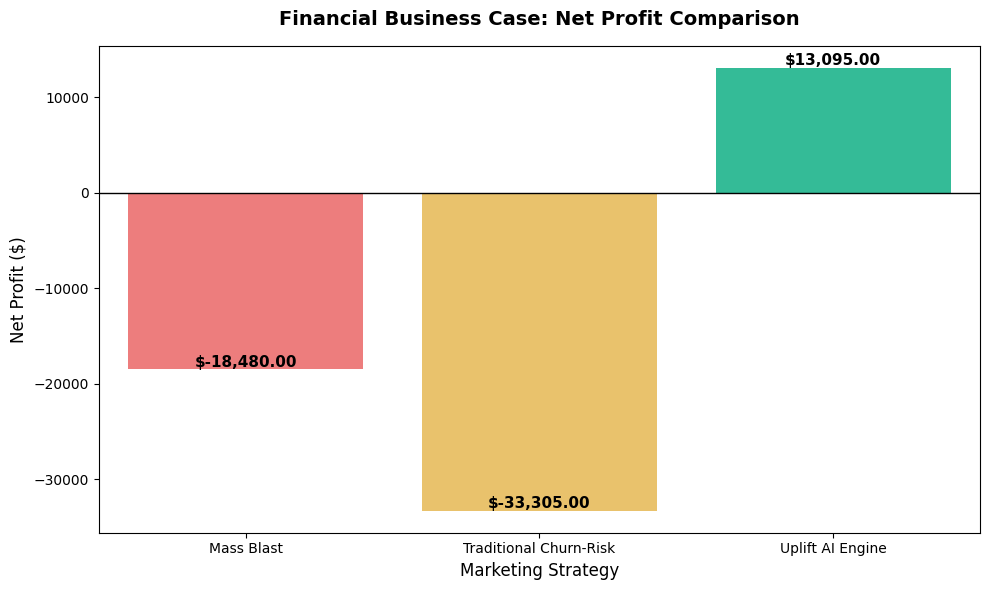

In [23]:
print("\nStep 2/2: Generating business presentation visualization...")

strategies = ['Mass Blast', 'Traditional Churn-Risk', 'Uplift AI Engine']
profits = [profit_all, profit_churn, profit_up]

plt.figure(figsize=(10, 6))
colors = ['#ff6b6b', '#feca57', '#1dd1a1'] # Red, Orange, Green

sns.barplot(x=strategies, y=profits, palette=colors, hue=strategies, legend=False)

# Formatting polish
plt.title('Financial Business Case: Net Profit Comparison', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Net Profit ($)', fontsize=12)
plt.xlabel('Marketing Strategy', fontsize=12)
plt.axhline(0, color='black', linewidth=1, linestyle='-')

# Add values on top of bars
for i, v in enumerate(profits):
    plt.text(i, v + (max(profits)*0.02), f"${v:,.2f}", ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()